In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = (
    pd.read_csv("unclean_smartwatch_health_data.csv")
    #Rename column names to fit Python naming rule
    .rename(columns = lambda col: col.strip().lower().replace(" ", "_").replace("(", "").replace(")", ""))
    #Convert ERROR to NAN using numpy
    .replace("ERROR", np.nan, regex = False).replace("Very High", np.nan, regex = False)
    #Drop null values
    .dropna()
    #Converted String figures to float
    .assign(sleep_duration_hours = lambda x: x["sleep_duration_hours"].astype(float))
    .assign(stress_level = lambda x: x["stress_level"].astype(int))
    .assign(activity_level = lambda x: x["activity_level"].str.replace("_", " ", regex = False).str.replace("Actve", "Active", regex = False)
            .str.replace(r"(.)\1+", r"\1", regex = True))
    #Drop column user id becaue variance = 0
    .drop(columns = ["user_id"])
)
df.head()

,heart_rate_bpm,blood_oxygen_level_%,step_count,sleep_duration_hours,activity_level,stress_level
0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1
3,40.000000,96.894213,13797.338044,7.367790,Active,3
5,96.285938,94.202910,10205.992256,8.378343,Highly Active,10
6,47.272257,95.389760,3208.781177,7.871146,Sedentary,2
7,81.733497,95.981343,6051.249857,5.224139,Sedentary,1


In [3]:
numeric_cols = ["heart_rate_bpm","blood_oxygen_level_%", "step_count", "sleep_duration_hours", "stress_level"]

In [ ]:
#Removing top 10% and bottom 5% outliers
lower_bound = df.select_dtypes("number").quantile(0.10)
upper_bound = df.select_dtypes("number").quantile(0.95)

filtered_data = (df[(df.select_dtypes("number") >= lower_bound) & (df.select_dtypes("number") <= upper_bound)]).all(axis = 1)

df.head()

,heart_rate_bpm,blood_oxygen_level_%,step_count,sleep_duration_hours,activity_level,stress_level
0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1
3,40.000000,96.894213,13797.338044,7.367790,Active,3
5,96.285938,94.202910,10205.992256,8.378343,Highly Active,10
6,47.272257,95.389760,3208.781177,7.871146,Sedentary,2
7,81.733497,95.981343,6051.249857,5.224139,Sedentary,1


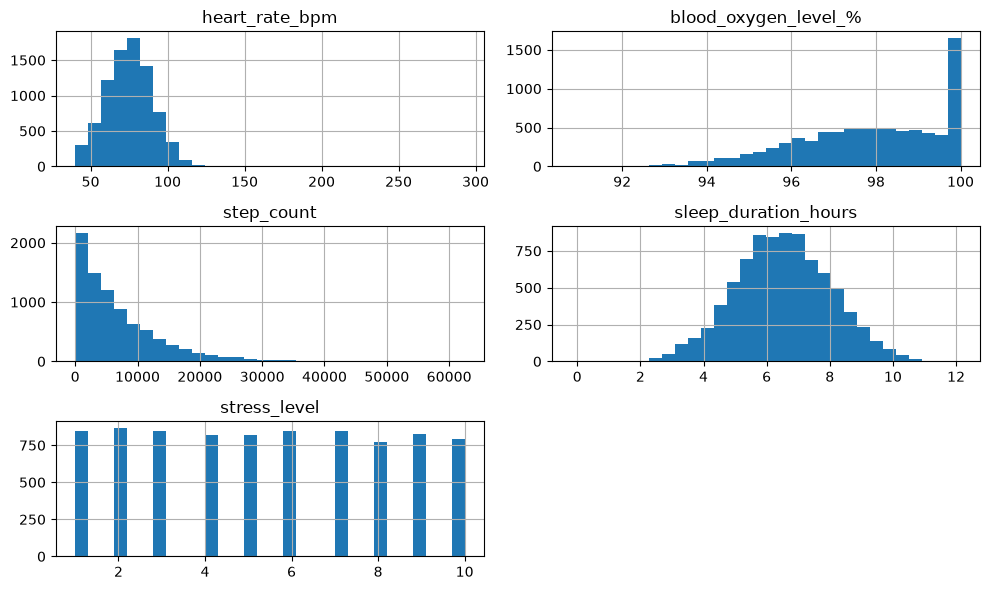

In [10]:
#Create histograms for each of the variables

df.select_dtypes("number").hist(figsize = (10, 6), bins = 30)
plt.tight_layout()
plt.show();

In [5]:
print(df["stress_level"].nunique())
#The stress_level column will be kept because nunique > 1. It equals 10 and counts are almost equal)
for col in numeric_cols:
    print(f"{col}: {df[col].describe()}")

10
heart_rate_bpm: count    8287.000000
mean       76.000396
std        19.030185
min        40.000000
25%        64.921323
50%        75.321211
75%        85.324321
max       292.923300
Name: heart_rate_bpm, dtype: float64
blood_oxygen_level_%: count    8287.000000
mean       97.837248
std         1.739699
min        90.791208
25%        96.654310
50%        98.001247
75%        99.377902
max       100.000000
Name: blood_oxygen_level_%, dtype: float64
step_count: count     8287.000000
mean      6996.275243
std       6904.773042
min          0.910138
25%       1994.654512
50%       4970.878786
75%       9765.357223
max      62486.690753
Name: step_count, dtype: float64
sleep_duration_hours: count    8287.000000
mean        6.504998
std         1.510821
min        -0.194453
25%         5.484881
50%         6.497615
75%         7.532584
max        12.140233
Name: sleep_duration_hours, dtype: float64
stress_level: count    8287.000000
mean        5.433691
std         2.869335
min         

In [17]:
#Build a correlation matrix for features
feat_matrix = df.select_dtypes("number").corr("spearman")
print(feat_matrix)

                      heart_rate_bpm  blood_oxygen_level_%  step_count  \
heart_rate_bpm              1.000000             -0.010889    0.011941   
blood_oxygen_level_%       -0.010889              1.000000    0.000228   
step_count                  0.011941              0.000228    1.000000   
sleep_duration_hours       -0.005923              0.003418   -0.000546   
stress_level               -0.005051             -0.011857    0.011544   

                      sleep_duration_hours  stress_level  
heart_rate_bpm                   -0.005923     -0.005051  
blood_oxygen_level_%              0.003418     -0.011857  
step_count                       -0.000546      0.011544  
sleep_duration_hours              1.000000     -0.007063  
stress_level                     -0.007063      1.000000  


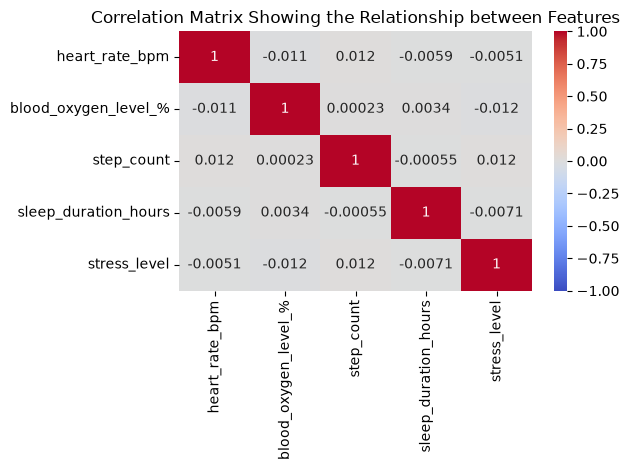

In [18]:
#Building a Heatmap for the Correlation Matrix
fig, ax = plt.subplots()
sns.heatmap(feat_matrix, annot = True, cmap = "coolwarm", vmin = -1, vmax = 1, ax = ax)
ax.set_title("Correlation Matrix Showing the Relationship between Features")
plt.tight_layout()
plt.show()